<a href="https://colab.research.google.com/github/ankit-281/Tasks_Ankit_GDG/blob/Task2/GDG_Task2_Ankit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**GDG TASK 2**

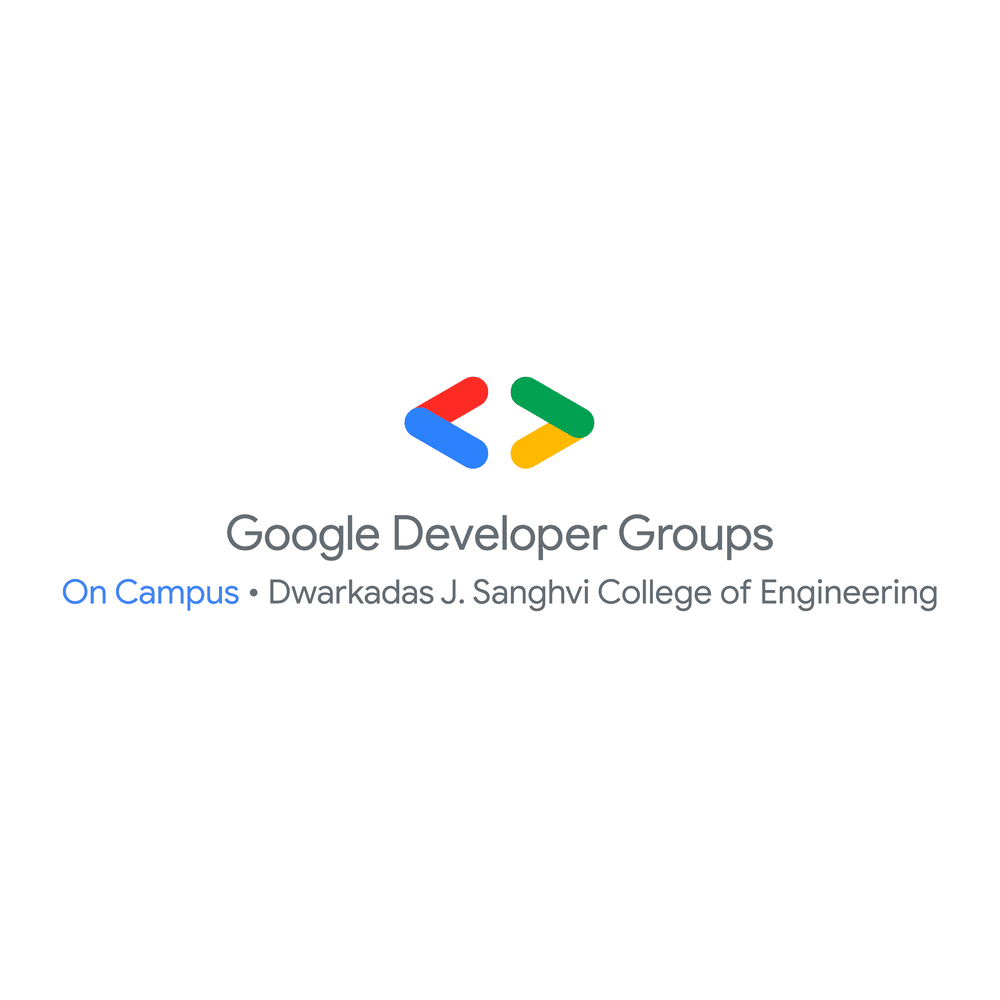

Last week, we dealt with the visualization and analytical aspect of ML. This week, lets directly get our hands dirty with various ML models.

Possibly the first question one must ask is, what is Machine Learning essentially made up of? In a broad sense, ML problems can be split into Supervised and Unsupervised learning. In supervised learning are the categories of Classification and Regression, which is what we'll explore today.

Like last time, resources and comments are provided above each cell, so peruse the resources and then get coding.

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

OPTIONAL BUT USEFUL <br>
Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [ ]:
!pip install shap -q  #Will be used later on

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mount your Google Drive using the cell below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Regression

For regression, lets reuse the crab dataset that you worked on last week. Import the dataset from wherever you had saved it in the cell below.
Also print the first 5 rows to ensure you have loaded the dataset correctly.

In [ ]:
df_crab = pd.read_csv('/content/drive/MyDrive/Datasets/Task1.csv')

In [ ]:
df_crab.shape

(74051, 10)

Now, let's some employ some Feature Engineering tactics which you would have performed in the previous tasks.

Create a function called crab_processing which takes a dataframe as an input, performs the following tasks, and returns a cleaned and edited df:

1) Drop the 'id' column.

2) Drop all rows where 'Height' of the crab is 0.

3) Create a new column called 'LostWeight' which is calculated using the following formula - ```
Weight - (Shucked + Viscera + Shell)``` .
If this formula gives a number less than 0, then assign 0 to the LostWeight column, else assign 1.

4) Finally, use one hot encoding to encode the column 'Sex'

Take help from your previous task where you have implemented these steps in different cells.


In [ ]:
# Your code starts here
def crab_processing(df):
  #logic for feature engineering
  df = df.drop('id',axis=1)
  df = df[df['Height']!=0]
  df.insert(
    df.columns.get_loc('Shell Weight')+1,
    'Lost Weight',
    np.where(df['Weight']-df['Shucked Weight']-df['Viscera Weight']-df['Shell Weight']>0, 1, 0)
  )
  df = pd.get_dummies(data=df,columns=['Sex'],dtype='int')
  return df

df_crab = crab_processing(df_crab)
df_crab.head()
# Your code ends here

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Lost Weight,Age,Sex_F,Sex_I,Sex_M
0,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,1,9,0,1,0
1,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,1,8,0,1,0
2,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,1,9,0,0,1
3,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,1,11,1,0,0
4,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,1,8,0,1,0


If all is correct, this should be the shape of your df now.

In [ ]:
df_crab.shape

(74027, 12)

###Basic Visualization

In this problem, our aim is to predict the age of the crab, hence 'Age' here is called our target variable. To check its distribution, plot a histogram of the 'Age' column.

Choose the number of bins by experimenting. The output is expected to mimic a bell curve.

What is a histogram? - https://www.w3schools.com/python/matplotlib_histograms.asp

Difference between histogram and a bar graph - https://keydifferences.com/difference-between-histogram-and-bar-graph.html

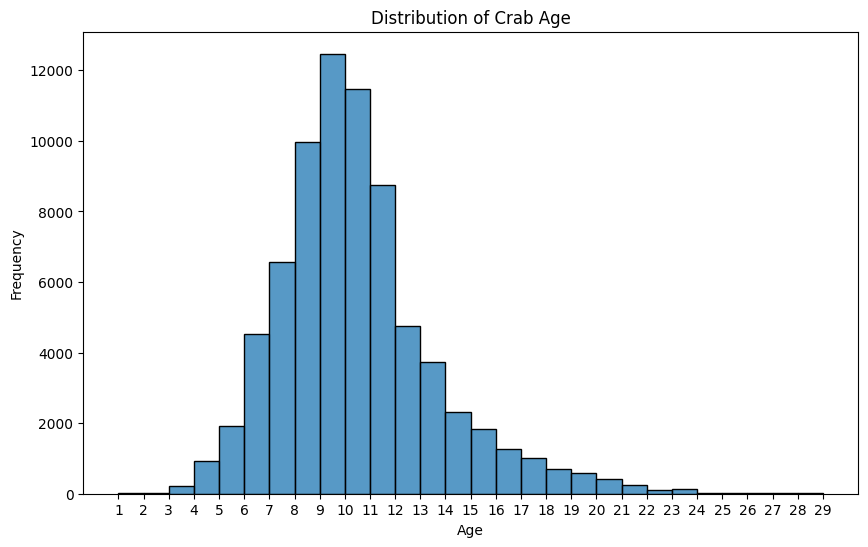

In [ ]:
# Your code starts here
plt.figure(figsize=(10, 6))
sns.histplot(df_crab['Age'], bins=28)  # Experiment with the 'bins' parameter
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Crab Age')
plt.xticks(ticks=range(int(df_crab['Age'].min()), int(df_crab['Age'].max()) + 1, 1))  # Adjust the step size as needed
plt.show()
# Your code ends here

###Feature and Variable Sets

As mentioned above, the 'Age' column is what we're gonna be predicting. So essentially we need to create two additional dataframes, one which contains all the training features (All columns except 'Age') and one which only contains the column 'Age'. Name them X and y respectively.

In [ ]:
# Your code starts here
X=df_crab.drop('Age',axis=1)
y=df_crab['Age']
# Your code ends here

In [ ]:
# This code should print (74027, 11) and (74027, 1) if everything is correct
print(X.shape,y.shape)

(74027, 11) (74027,)


In [ ]:
#Print a few records of X
X.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Lost Weight,Sex_F,Sex_I,Sex_M
0,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,1,0,1,0
1,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,1,0,1,0
2,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,1,0,0,1
3,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,1,1,0,0
4,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,1,0,1,0


In [ ]:
#Print a few records of y
y.head()

,Age
0,9
1,8
2,9
3,11
4,8


###Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [ ]:
# Import train_test_split Hint: Use sklearn.model_selection
from sklearn.model_selection import train_test_split

**Create X and y train and test splits in one command using a test size of 0.3 and a random seed**

They should be called X_train, X_test, y_train, y_test

In [ ]:
# Your code starts here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Your code ends here

Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [ ]:
# Your code starts here
X_train.shape, X_test.shape, y_train.shape, y_test.shape
# Your code ends here

((51818, 11), (22209, 11), (51818,), (22209,))

Can you see that the data has been divided into 2 datasets of size 70% and 30% of the original dataset each? Use your calculator to confirm this :)

###Model fit and training

Here is the complete lowdown on SVM (Support Vector Machine):<br>
Theory : https://youtu.be/H9yACitf-KM <br>
Theory: https://www.analyticsvidhya.com/blog/2021/06/support-vector-machine-better-understanding/ <br>
Implementation : https://youtu.be/FB5EdxAGxQg

Import SVR (Support Vector Regressor) and its metrics from scikit-learn.

In [ ]:
# Add your import statement here
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
# Create an SVR object 'svr' by calling SVR()
svr = SVR()

Fit the model on to the instantiated object itself using the X_train and y_train created earlier. No need to create another variable.

Hint: svr.fit()

This might take about a minute or so, just to inform you.

In [ ]:
# Your code starts here
svr.fit(X_train, y_train)
# Your code ends here

SVR()

###Prediction, error estimate, and regression evaluation matrices

**Prediction using the svr model**

The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

Use svr.predict() on X_test and store it in a variable called "predictions". Print type and size of the predictions.

Size should be (22009,) if everything is correct.

In [ ]:
# Your code starts here
predictions = svr.predict(X_test)
print(type(predictions), predictions.shape)
# Your code ends here

<class 'numpy.ndarray'> (22209,)


Now that we have our predictions, let's compare it with y_test and see how accurate our predictions are.

Plot a Scatter plot of predicted price and y_test set to see if the data falls on a 45 degree straight line

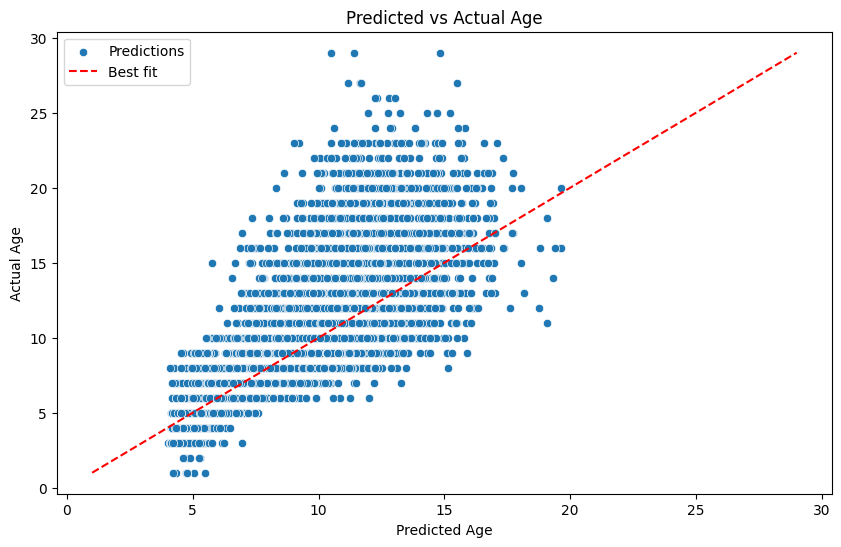

In [ ]:
# Your code starts here
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=y_test)

min_val = min(min(predictions), min(y_test))
max_val = max(max(predictions), max(y_test))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('Predicted Age')
plt.ylabel('Actual Age')
plt.title('Predicted vs Actual Age')
plt.legend(['Predictions', 'Best fit'])
plt.show()
# Your code ends here

As you can see, it's not perfect, but you can definitely visualize the data lining up at a 45 degree angle.

**Model Evaluation**

We will be exploring the most common regression metric here namely R2 score. You can check out more metrics here: https://scikit-learn.org/stable/modules/classes.html#regression-metrics

Here's a video detailing all the popular regression metrics - https://www.youtube.com/watch?v=Ti7c-Hz7GSM

**Print the R-square value and round it to 3 decimal places**

Hint: sklearn metrics.r2_score

In [ ]:
# Your code starts here
r_squared = r2_score(y_test, predictions)
print("R-squared value:", round(r_squared, 3))
# Your code ends here

R-squared value: 0.551


In the cell below, explain what the above score means and also elaborate how 'good' is the score in terms of evaluation of the model

Your text here




R-squared score quantifies how well the independent variables in the model predict the dependent variable. A score of 0.551 means that 55.1% of the variability in the target variable (age of the crab) can be explained by the features (all the columns except age) used in the svr model.

It is not a very good score.

In [ ]:
#Explore additional metrics here
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Mean Squared Error (MSE):", round(mse, 3))
print("Root Mean Squared Error (RMSE):", round(np.sqrt(mse), 3))

Mean Absolute Error (MAE): 1.388
Mean Squared Error (MSE): 4.417
Root Mean Squared Error (RMSE): 2.102


MAE of 1.388 indicates that, on average, the model's predictions are about 1.388 years off from the actual ages of the crabs.

The MSE and RMSE values are more sensitive to outliers and hence higher.

This is quite good

You have succesfully implemented Support Vector Regressor to predict Age of a crab. But is this the only regression model out there? In the cell below, list down 3 more regression models with a basic explanation of how they work. Also include a line explaining in which scenario each model works best.

Your text here

### Linear Regression
Linear regression establishes a relationship between the dependent variable (target) and one or more independent variables (features) by fitting a linear equation to the observed data. The model assumes that the relationship between the variables can be represented as a straight line.

It works best when there is a linear relationship between the independent and dependent variables, and the data does not contain outliers that can disproportionately affect the model.

### Decision Tree Regressor
A decision tree regressor splits the dataset into subsets based on the values of the input features, creating a tree-like structure. Each internal node represents a feature, each branch represents a decision rule, and each leaf node represents the predicted outcome. The predictions are made by traversing the tree based on input feature values.

This model is well-suited for datasets with non-linear relationships and interactions between features, and it can handle both numerical and categorical data effectively.

### Random Forest Regressor
A random forest regressor builds multiple decision trees during training and merges their predictions to improve accuracy and control over-fitting. Each tree is trained on a random subset of the data and features, and the final prediction is usually made by averaging the predictions from all trees.

It works best when there are complex relationships in the data, as it can capture interactions and non-linear patterns better than a single decision tree. It is also robust to outliers and noise.

###Explainability

So you passed some data into a model, and trained it using that data. You then used some other data to test the accuracy of that model, and it now predicts values when you pass in some data. Ok. But how does it REALLY predict that value? How much is it relying on each individual feature column of data that you passed to the model? This is where the concept of explainability comes into picture, where you can understand for each data point, exactly what parameters led the model to predict the value that it has.

Info about explainable AI <br>
https://www.ibm.com/topics/explainable-ai <br>
About shap <br>
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

In [ ]:
#Run this code as it is
from shap import KernelExplainer, force_plot, sample

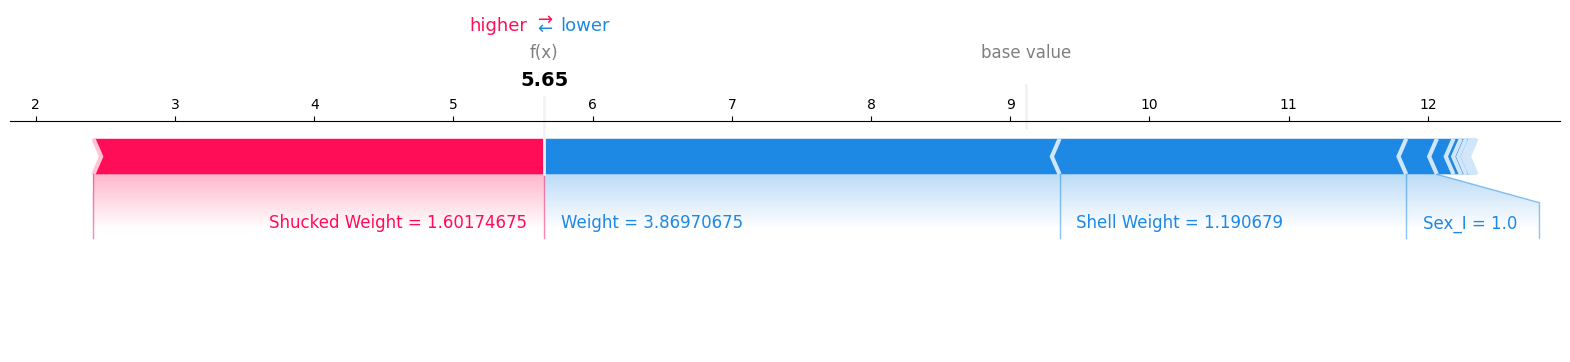

In [ ]:
#Run this code as it is
ex = KernelExplainer(svr.predict, sample(X_train, 10))  #only taking sample of 10 values for now
shap_values = ex.shap_values(X_test.iloc[0,:]) #explaining 1st tuple of the X_test dataframe
force_plot(ex.expected_value, shap_values, X_test.iloc[0,:], matplotlib=True)

Can you see how the above plot visualizes which parameters contributed significantly to the prediction, and what were the actual values which led to the prediction?

##Classification

In the below cells, we are going to implement K Nearest Neighbour Classification.

Link to the dataset is here - https://drive.google.com/file/d/1bVOfBJYUr0JtZ7pp1lcyNamnHHXn_fDm/view?usp=sharing <br>

Import the 'classified_data.txt' dataset using pandas and print the first five columns.

Use "index_col" parameter to index the dataframe according to the first column. Otherwise, a new column would get created. Call this new dataframe 'df'.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/classified_data.txt',index_col=0)
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


If you're wondering what these column names signify, well they are classified as the dataset name suggests. Our job here is to simply take the data at face value and build a model for classifying the target classes.

###Basic EDA

In the following two cells, use info() and describe() to get the data type and statistical summary of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 93.8 KB


In [ ]:
df.describe()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


**Run a 'for' loop to draw boxplots of all the features for '0' and '1' TARGET CLASS**<br>
Hint: Loop through each of the 10 features and draw a separate boxplot. You should have 10 boxplots in total. <br>
Refer seaborn boxplot() documentation

Here is some information about boxplots:

Understanding Boxplots:
https://medium.com/analytics-vidhya/introduction-to-box-plots-and-how-to-interpret-them-22464acbcba7 <br>
Comparing two boxplots: https://www.nagwa.com/en/explainers/812192146073/

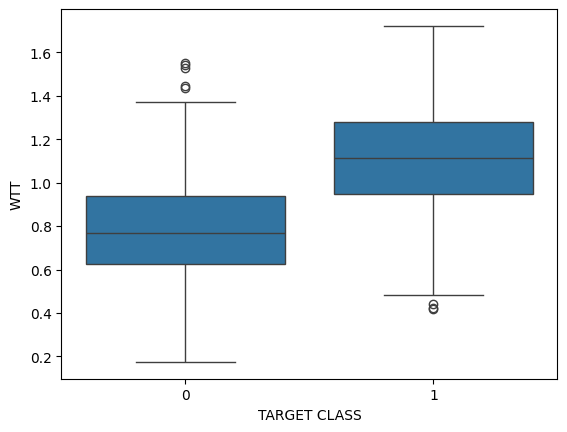

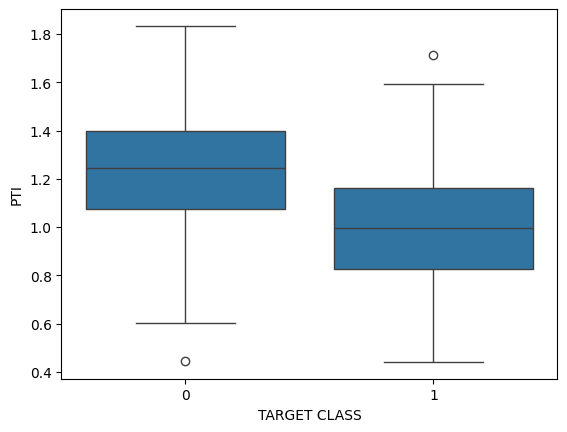

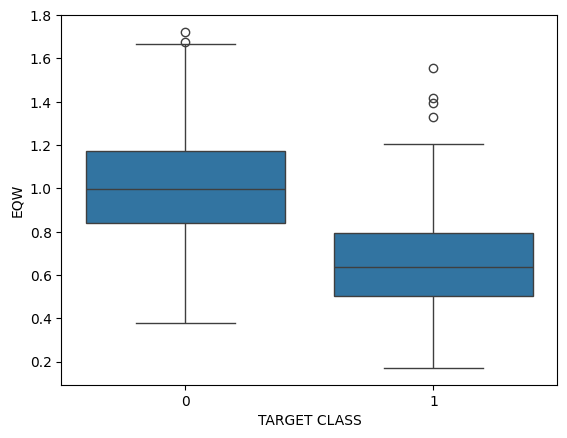

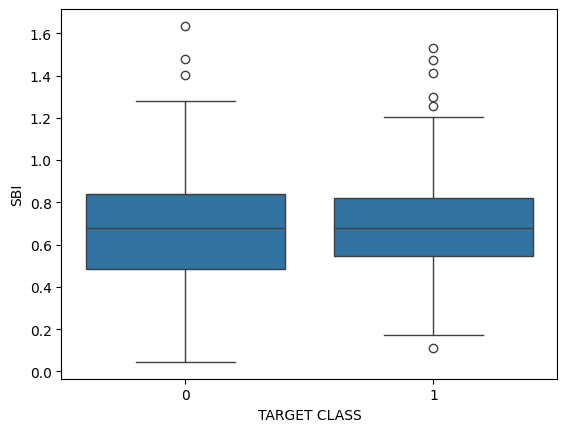

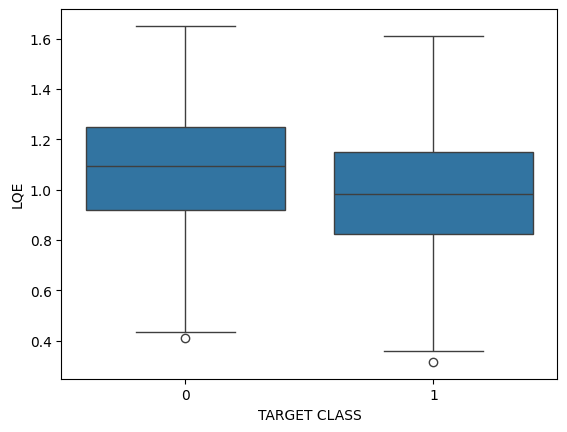

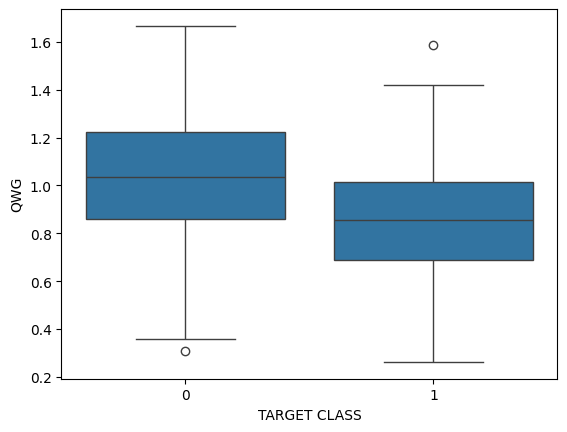

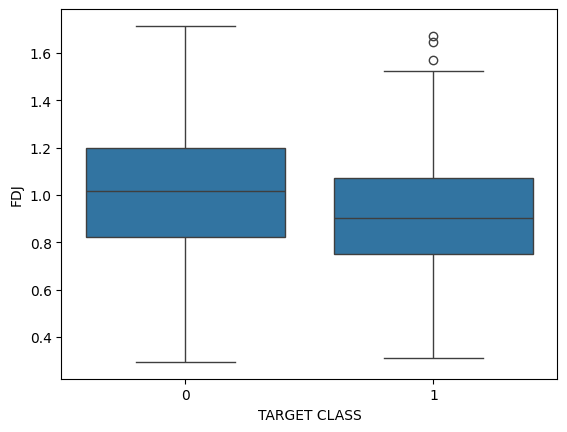

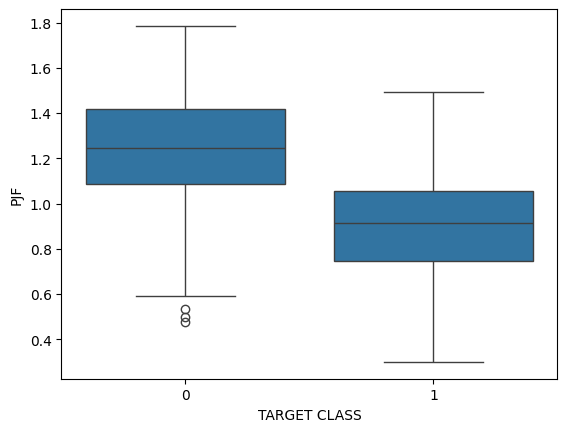

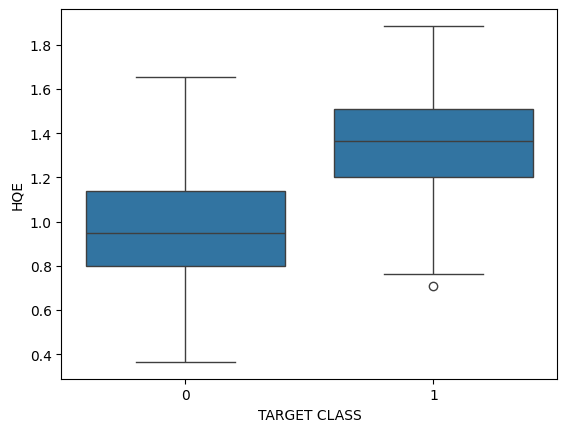

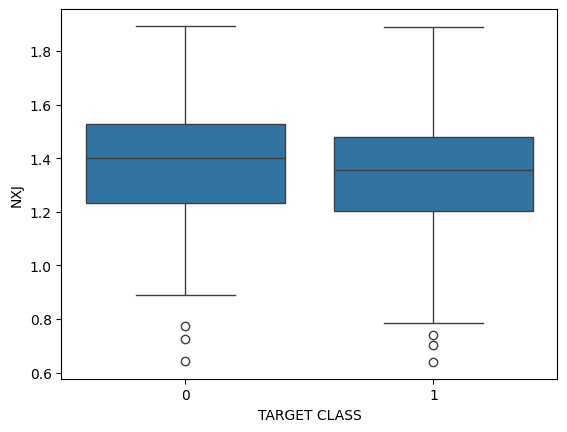

In [ ]:
# your code starts here
for i in df.columns[:-1]:
  sns.boxplot(x='TARGET CLASS', y=i, data=df)
  plt.show()
# your code ends here

What conclusion, if any can you draw from these boxplots?
List them down below.

Text here

### For classification of target class:

Bad features: SBI and NXJ (since inter-quartile ranges line up)

Decent features: FDJ, QWG, LQE (since interquartile ranges are seperated by only a tiny bit)

Good features: HQE, PJF, EQW, PTI, WTT (since interquartile ranges are well seperated)

### Standardize the features using sklearn.preprocessing
Why should we standardize?<br>
Variables that are measured at different scales do not contribute equally to the model fitting & model learned function and might end up creating a bias. Thus, to deal with this potential problem feature-wise standardization is usually used prior to model fitting.<br><br>

To give you an example, values pertaining to Age usually lie within the range of 1-100, however values pertaining to Salary lie in a much wider range of say 10000-1000000. You can see how having both columns be a part of a classification model as is would lead to an imbalance in importance assigned to columns.
<br><br>
Go through this link for a better understanding:<br>
https://towardsdatascience.com/how-and-why-to-standardize-your-data-996926c2c832

**import StandardScaler from Sklearn and instantiate it to a variable called "scaler"**

In [ ]:
# your code starts here
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# your code ends here

**Fit only the features data to this scaler (leaving the TARGET CLASS column out) and then transform**<br>
Hint: scaler.fit() and scaler.transform()

In [ ]:
# your code starts here
scaler.fit(df.drop('TARGET CLASS',axis=1))
scaled_features = scaler.transform(df.drop('TARGET CLASS',axis=1))
# your code ends here

In [ ]:
scaled_features

array([[-0.12354188,  0.18590747, -0.91343069, ..., -1.48236813,
        -0.9497194 , -0.64331425],
       [-1.08483602, -0.43034845, -1.02531333, ..., -0.20224031,
        -1.82805088,  0.63675862],
       [-0.78870217,  0.33931821,  0.30151137, ...,  0.28570652,
        -0.68249379, -0.37784986],
       ...,
       [ 0.64177714, -0.51308341, -0.17920486, ..., -2.36249443,
        -0.81426092,  0.11159651],
       [ 0.46707241, -0.98278576, -1.46519359, ..., -0.03677699,
         0.40602453, -0.85567   ],
       [-0.38765353, -0.59589427, -1.4313981 , ..., -0.56778932,
         0.3369971 ,  0.01034996]])

**scaler.transform() will return an array. We need to convert this into a dataframe. Do this and add the column names to the dataframe. Call this new dataframe as "df_feat". Call head() on this df**<br>
Note: The final dataframe will have the initial columns except the "TARGET CLASS".

In [ ]:
# your code starts here
df_feat = pd.DataFrame(scaled_features,columns=df.drop('TARGET CLASS',axis=1).columns)
df_feat.head()
# your code ends here

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


### Train/Test split

**Set X to be equal to df_feat and set y accordingly. As you know, X contains our training features and y contains our target.**<br>
Hint: y can be taken directly from the initial dataframe "df"

In [ ]:
# Your code starts here.
X = df_feat
y = df['TARGET CLASS']
# Your code ends here

**Import train_test_split function from scikit-learn**<br>
**Create X and y train and test splits in one command using a test size of 0.3 and a random seed**<br>
They should be called X_train, X_test, y_train, y_test

In [ ]:
# Your code starts here.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Your code ends here

### Model fit and training

Before moving ahead with the cells below, learn how the K Nearest Neighbour Algorithm actually works.

Theory and implementation : https://youtu.be/wTF6vzS9fy4 <br>
Theory: https://www.analyticsvidhya.com/blog/2018/08/k-nearest-neighbor-introduction-regression-python/

**import KNeighborsClassifier from sklearn and initialize it with neighbours = 1 (more on this later) . Fit this on X_train and y_train**

In [ ]:
# Your code starts here.
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
# Your code ends here

KNeighborsClassifier(n_neighbors=1)

**Using this fitted model, predict on X_test. Store these predictions in variable called pred.**

In [ ]:
# Your code starts here.
pred = knn.predict(X_test)
pred
# Your code ends here

array([0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

**Let us check how correct these predictions are.<br>
Print a classification report of y_test and pred**<br>
Hint: sklearn classification_report

In [ ]:
# Your code starts here.
from sklearn.metrics import classification_report, confusion_matrix, log_loss
print(classification_report(y_test,pred))
# Your code ends here

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       142
           1       0.95      0.93      0.94       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



Learn all about classification metrics - https://medium.com/analytics-vidhya/evaluation-metrics-for-classification-models-e2f0d8009d69

In [ ]:
print(confusion_matrix(y_test,pred))
print(log_loss(y_test, pred))

[[134   8]
 [ 11 147]]
2.282764714644087


**Print the accuracy using numpy and round it to 3 decimal places.**

In [ ]:
# Your code starts here.

accuracy = np.mean(pred == y_test)
print("Accuracy:", round(accuracy, 3))

# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(y_test, pred)
# print("Accuracy:", round(accuracy, 3))
# this also works which uses numpy too behind the curtains


# Your code ends here

Accuracy: 0.937


Hey, not bad! But can we further improve this? Remember our arbitrary choice for n_neighbours? Can we improve that?

### Choosing optimal 'k'

**Above, we chose n_neighbours to be equal to 1. Choosing a small value of K leads to unstable decision boundaries. <br>
We need to select n_neighbours by calculating the accuracy for every value of n from 1 to 60 and then choosing the one which gives the highest accuracy.**

In [ ]:
# Do the same as we did above, but this time make a loop from n = 1 to n = 60 and append the accuracy
# for each in a list

# Your code starts here.
accuracy_list = [] # list to store accuracy values for k ranging from 1 to 60
for k in range(1,61):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred=knn.predict(X_test)
    accuracy = round(np.mean(pred == y_test), 3)
    accuracy_list.append(accuracy) # storing accuracy values
    print(f'Accuracy for k= {k} is: {accuracy}')
# Your code ends here

Accuracy for k= 1 is: 0.937
Accuracy for k= 2 is: 0.917
Accuracy for k= 3 is: 0.943
Accuracy for k= 4 is: 0.943
Accuracy for k= 5 is: 0.943
Accuracy for k= 6 is: 0.943
Accuracy for k= 7 is: 0.937
Accuracy for k= 8 is: 0.943
Accuracy for k= 9 is: 0.943
Accuracy for k= 10 is: 0.95
Accuracy for k= 11 is: 0.95
Accuracy for k= 12 is: 0.953
Accuracy for k= 13 is: 0.953
Accuracy for k= 14 is: 0.953
Accuracy for k= 15 is: 0.953
Accuracy for k= 16 is: 0.953
Accuracy for k= 17 is: 0.953
Accuracy for k= 18 is: 0.95
Accuracy for k= 19 is: 0.947
Accuracy for k= 20 is: 0.947
Accuracy for k= 21 is: 0.95
Accuracy for k= 22 is: 0.943
Accuracy for k= 23 is: 0.943
Accuracy for k= 24 is: 0.947
Accuracy for k= 25 is: 0.94
Accuracy for k= 26 is: 0.943
Accuracy for k= 27 is: 0.947
Accuracy for k= 28 is: 0.947
Accuracy for k= 29 is: 0.95
Accuracy for k= 30 is: 0.95
Accuracy for k= 31 is: 0.95
Accuracy for k= 32 is: 0.95
Accuracy for k= 33 is: 0.95
Accuracy for k= 34 is: 0.95
Accuracy for k= 35 is: 0.95
Accura

**Plot a graph of K value vs Accuracy**

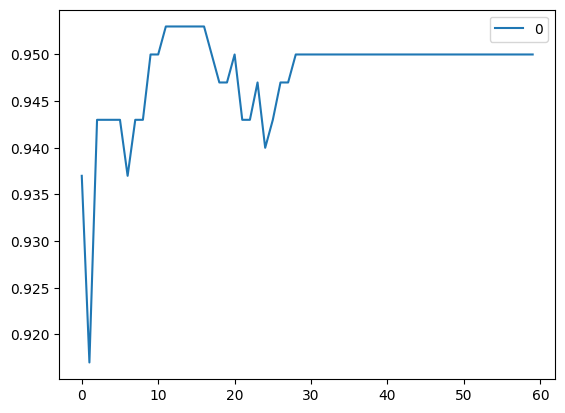

In [ ]:
# Your code starts here.
curve = pd.DataFrame(accuracy_list)
curve.plot()
plt.show()
# Your code ends here

**Choose the best value of n_neighbours and give a reason why and also print the accuracy**

In [ ]:
# Your code starts here.
n_acc_best = 0.953
n_neigh_best = 15
print("Best value of n_neighbours:",n_neigh_best)
print("Corresponding highest accuracy:",n_acc_best)
# Your code ends here

Best value of n_neighbours: 15
Corresponding highest accuracy: 0.953


In [ ]:
# Reasons:
# Chose value of n_neighbours as 15 since it is one of the 6 n_neighbour values that gives the highest accuracy of the knn classifier model, i.e. 95.3%

# **Compulsory:**

Task 1 : You have to research and create a short blog on the topic of **Reinforcement Learning**.


Task 2 : You have to research and create a short blog on the topic of **Oversampling and Undersampling**.
Happy coding! :)

## **Reinforcement Learning**
Reinforcement Learning (RL) is an upcoming branch of machine learning where models learn by interacting with an environment and receiving rewards or penalties. Unlike supervised learning, where an agent learns from labeled data, RL models learn optimal actions over time by maximizing cumulative rewards.

### What is Reinforcement Learning?
In RL, an agent (a decision-maker) interacts with an environment to achieve a goal. At each step, the agent takes an action, receives feedback in the form of a reward or penalty, and then adjusts its strategy. Over time, the agent learns the best actions to take in different situations through trial and error.

### Core Concepts in Reinforcement Learning
Agent: The agent is the decision-maker in RL, responsible for taking actions in the environment. It can be a robot, a computer program, or even a self-driving car.

Environment: The environment is everything outside the agent. It provides feedback to the agent based on its actions and may include other agents or a simulated world, like a game or a complex system.

State: The state represents the current situation of the environment that the agent can observe. In a chess game, for example, the board configuration is the state.

Action: An action is a move the agent takes to change the state. Each action moves the agent closer to or further from its goal, depending on how well it performs.

Reward: After each action, the agent receives a reward (a numerical score) indicating how beneficial the action was. The reward system guides the agent, motivating it to achieve maximum cumulative reward. In a game, the reward might be points gained or lost.

Policy: The policy is the agent's strategy, mapping from states to actions. It determines which action the agent takes in a given state. Policies can be deterministic (fixed actions for states) or stochastic (probabilistic selection of actions).

Value Function: The value function predicts the long-term benefit of being in a certain state (or state-action pair). It helps the agent plan future actions by considering potential future rewards.

Q-value (Quality Value): The Q-value function estimates the expected cumulative reward for taking an action in a specific state. It's particularly useful in Q-learning, a popular RL algorithm.

### Why is Reinforcement Learning Important?


1.   Real-Life Simulation: Many real-world problems require a series of decisions that lead to future outcomes, like navigating a maze, playing a game, or managing an industrial process. RL shines in these situations by learning from sequences of actions and feedback.
2.   Dynamic Environments: RL doesn't just optimize for a single action—it optimizes strategies that evolve over time. This ability to respond dynamically is crucial for applications like autonomous vehicles, robotics, and financial trading, where conditions constantly change.
3.  Self-Improvement through Feedback: Unlike supervised learning, where the agent learns from a fixed dataset, RL agents learn directly from their interactions with an environment. They explore, make mistakes, receive rewards or penalties, and adjust their strategies accordingly, leading to a process of continuous improvement.
4.  Adaptability: RL equips agents to adapt based on the feedback loop of interaction and response. This adaptability allows RL agents to handle new, unseen situations, making them robust in environments with uncertain outcomes.
5.  Solving Label-Scarce Problems: Labeling data can be labor-intensive and costly, especially in complex domains like robotics or healthcare. RL bypasses this by learning through rewards, which can often be more easily defined than manual labels.
6.  Taking Advantage of Simulation: In many applications, RL agents are trained in simulations that mimic real-world conditions. For example, in healthcare, models can simulate patient responses to treatments, avoiding the need for real-world experiments. In robotics, virtual environments let robots learn without the risk of physical damage.
7.  Optimizing for Long-Term Rewards: RL encourages agents to think about future rewards rather than just immediate gains. This feature is particularly valuable in areas like sustainability and energy management, where short-term actions can impact long-term outcomes.

### Where is Reinforcement Learning Used?


1.   Gaming: RL has made headlines for its use in games. Agents trained with RL can master complex games like chess, Go, and even real-time strategy games like StarCraft II. AlphaGo, developed by DeepMind, famously beat human champions by leveraging RL.
2.   Robotics: In robotics, RL helps agents learn complex tasks, like grasping objects, navigating spaces, and avoiding obstacles, by interacting with their environment.
3.  Self-Driving Cars: RL is used to train autonomous vehicles to make real-time decisions based on sensor data. Agents learn to navigate roads, avoid collisions, and adapt to new driving conditions.
4.  Healthcare: RL applications in healthcare include optimizing treatment plans, managing personalized therapies, and predicting patient responses to treatments. For instance, it can help adjust insulin dosage for diabetic patients by predicting blood glucose levels.
5.  Finance: In financial markets, RL helps develop trading algorithms that maximize profits while managing risk. Agents can learn optimal strategies for buying, selling, and holding assets over time.

### Challenges in Reinforcement Learning:
While RL is powerful, it faces some significant challenges:

1.   Sample Efficiency: RL often requires a massive amount of data to learn effectively, especially in complex environments. Gathering this data can be time-consuming and computationally expensive.
2.   Exploration vs. Exploitation: The agent must balance exploration (trying new actions to discover rewards) with exploitation (choosing the best-known action to maximize rewards). Achieving the right balance is crucial to efficient learning.
3.  Delayed Rewards: In some environments, the rewards are not immediate, making it challenging for the agent to associate actions with future rewards. RL algorithms address this using discounted future rewards, but it’s still a complex problem.
4.  Scalability: For high-dimensional or continuous spaces, standard RL methods can become computationally infeasible. Deep learning has helped, but there’s still a need for more efficient algorithms.
5.  Safety and Ethics: In critical applications like healthcare and autonomous driving, ensuring that RL agents behave safely and ethically is essential. Mistakes made by an RL model in a simulated environment are fine, but in real life, they can have serious consequences.

### Conclusion:
Reinforcement Learning holds immense promise for advancing AI capabilities, enabling agents to learn and make decisions in complex, dynamic environments. Despite its challenges, RL continues to push the boundaries of machine learning, showing potential in diverse fields, from gaming and robotics to finance and healthcare. As algorithms become more efficient and scalable, RL could lead to even more transformative applications.




## **Oversampling and Undersampling**

Dealing with imbalanced datasets is a common challenge in machine learning. When one class is significantly underrepresented, models can become biased, favoring the majority class. Two effective techniques to handle this issue are oversampling and undersampling.

### What are Oversampling and Undersampling?
Oversampling and undersampling are data preprocessing techniques that adjust the distribution of classes within a dataset. In oversampling, we increase the number of instances in the minority class, often by duplicating samples or generating synthetic ones. The popular SMOTE (Synthetic Minority Over-sampling Technique) generates new samples by interpolating between existing ones. Undersampling, on the other hand, reduces the instances in the majority class by randomly removing samples, helping to balance the class distribution without altering the minority class.

### Why Use Oversampling and Undersampling?
Imbalanced data can lead to biased predictions, where models struggle to correctly classify the minority class. Oversampling and undersampling address this by ensuring each class has a more balanced representation. This improves the model's ability to learn patterns from all classes, leading to better overall performance, particularly in classification problems.

### When to Use Oversampling
1.   Small Dataset: If the dataset is small, oversampling is preferable because it keeps all available data intact. Removing samples in a small dataset could lead to a loss of valuable information.
2.   Imbalanced Classes with Rare Events: When the minority class is crucial (e.g., fraud detection, rare disease detection), oversampling ensures the model sees enough minority class examples, which can improve recall for rare events.
3.  No Risk of Overfitting: Oversampling, especially when done by duplicating instances, can lead to overfitting. This is less of an issue if you're using techniques like SMOTE or if you have a complex model that generalizes well (e.g., deep learning models with regularization).
4.  Complex Data: For high-dimensional data, like text or image data, oversampling often works better since the features are more complex and require more samples to generalize accurately.

### When to Use Undersampling
1.   Large Dataset: When you have a large dataset, undersampling can be effective because reducing the majority class size still leaves enough data for the model to learn effectively.
2.   Minority Class Isn't Rare: If the minority class is slightly underrepresented but not extremely rare, undersampling can help balance the classes without needing to synthesize or duplicate samples.
3.  Risk of Overfitting: In cases where the model is likely to overfit, especially with simple models (e.g., decision trees), undersampling can reduce this risk by limiting the majority class.
4.  Resource Constraints: Undersampling reduces data size, which can be helpful when dealing with storage or computational limitations. It's often faster and more memory-efficient.

### Where is Oversampling and Undersampling Applied?
These techniques are widely used in areas like fraud detection, medical diagnosis, and text classification, where class imbalance is common. For instance, in fraud detection, fraudulent transactions are rare but crucial to identify. By applying oversampling, the model gets more exposure to fraud cases, enhancing its ability to catch them.

### Hybrid Approaches
Sometimes, combining both techniques can yield better results. For example, a slight undersampling followed by oversampling with SMOTE can help balance the classes without overly duplicating data or removing too much of the majority class.

Choosing the right technique depends on experimentation, but balancing class representation thoughtfully often leads to improved model performance.

Oversampling and undersampling are essential tools for creating robust, fair models, allowing machine learning algorithms to work effectively even in the face of imbalanced data.

## Conclusion
Oversampling and undersampling are essential techniques for handling imbalanced datasets, each with unique strengths depending on the context. Oversampling is ideal for preserving information in smaller datasets and handling rare events by providing more instances for the minority class. Undersampling, on the other hand, can be more efficient with large datasets by reducing the majority class and minimizing the risk of overfitting. By choosing the right approach—or combining both, we can ensure a balanced representation of classes, resulting in fairer, more accurate machine learning models that perform well across various applications, from healthcare to fraud detection.

# **End of Task**


